# Important Packages

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set global font sizes

In [19]:
import matplotlib as mpl
# Set global font sizes
mpl.rcParams.update({
    'font.size': 12,             # Base font size
    'axes.titlesize': 14,        # Title size of each subplot
    'axes.labelsize': 12,        # x and y axis label size
    'xtick.labelsize': 12,       # X tick label size
    'ytick.labelsize': 12,       # Y tick label size
    'legend.fontsize': 12,       # Legend text size
    'figure.titlesize': 12,      # Main figure title
    'legend.fontsize': 12        # Legend text size
})


# Using the Same SSA (Gillespie Algorithm)

In [3]:
# ============================================================
# Gillespie Algorithm
# ============================================================
def gillespie_algorithm(init_state, vectors, propensities, max_time):  
    state = np.array(init_state)
    time = 0.0
    times = [time]
    states = [state.copy()]
    
    while time < max_time:
        a = np.array(propensities(state))
        a0 = np.sum(a)
        if a0 == 0:
            break

        r1, r2 = np.random.uniform(0, 1, 2)
        h = (1/a0) * np.log(1/r1)
        cumsum_a = np.cumsum(a)
        vector_index = np.searchsorted(cumsum_a, r2 * a0)

        time += h
        state += vectors[vector_index]

        times.append(time)
        states.append(state.copy())
    
    return times, states


# - Disruption rates and the initial values with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.5$ (frequent disruption)

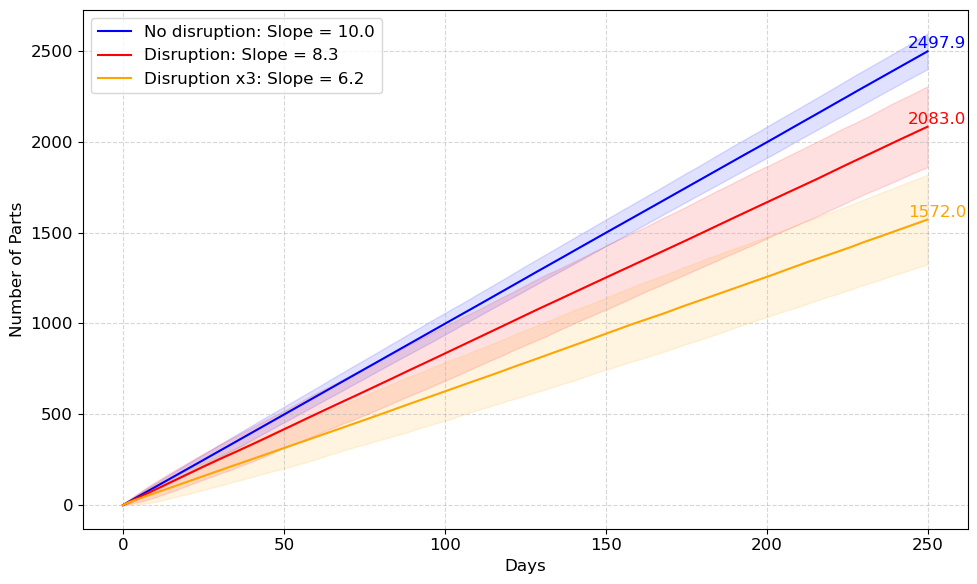

In [4]:
# ============================================================
# System definition: single reaction with disruption
# Y = (X, U1)
# ============================================================
lambda1 = 10.0                   # work (production)
lambda2_base = 0.1               # base failure
lambda3 = 0.5                    # repair

gene_vectors = [
    (+1,  0),   # work
    ( 0, -1),   # failure
    ( 0, +1)    # repair
]

init_state = [0, 1]
max_time = 250
num_simulations = 500

# ============================================================
# Scenario definitions
# ============================================================
scenarios = [("No disruption", 0.0),("Disruption", 1.0),("Disruption x3", 3.0),]

# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [lambda1 * U1,        # work
                lam2 * U1,           # failure (scaled)
                lambda3 * (1 - U1)   # repair
            ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results: mean X(t) for each lambda_2 = q_{1,0} scenario
# ============================================================
plt.figure(figsize=(10, 6))

# ============================================================
# Slope function
# ============================================================
def slope_from_scale(scale):
    lambda2 = lambda2_base * scale
    slope = lambda1 * (lambda3 / (lambda2 + lambda3))
    return slope
    
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    # Plot mean trajectory
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {slope_from_scale(scale):.1f}")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # ---- Auto-label offset logic ----
    if label == "No disruption":
        y_offset = 0
    elif label == "Disruption":
        y_offset = 0
    else:  # "Disruption x3"
        y_offset = 0

    # ---- Place label near the right end ----
    plt.text(t_grid[-1]- 6, X_mean[-1] + y_offset, f"{X_mean[-1]:.1f}", color=color, va="bottom")

plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption1.png", dpi=200, format="png", bbox_inches="tight")
plt.show()    

# Performance metrics across disruption and repair rates

In [60]:
disruption_rates = np.linspace(0.01, 3, 5)
repair_rates = np.linspace(0.001, 10, 7)
num_simulations = 100
max_time = 250
lambda1 = 10.0                   # work (production)

results = []

for q_01 in repair_rates:
    for q_10 in disruption_rates:

        # Update rates
        lambda2 = q_10
        lambda3_current = q_01

        def prop(state):
            X, U1 = int(state[0]), int(state[1])
            return [lambda1 * U1,                  # work
                    lambda2 * U1,                  # failure
                    lambda3_current * (1 - U1)     # repair
                ]

        # Run simulations
        X_interp = np.zeros((num_simulations, len(t_grid)))

        for i in range(num_simulations):
            times, states = gillespie_algorithm(init_state, gene_vectors, prop, max_time)
            states = np.array(states)
            X_vals = states[:, 0]

            X_interp[i] = np.interp(t_grid, times, X_vals)

        # ===== Metrics =====
        Expected_output = X_interp[:, -1].mean()
        Throughput = Expected_output / max_time

        Expected_nominal = lambda1 * max_time
        Loss = 1 - (Expected_output / Expected_nominal)
        
        # Store results
        results.append({"q_10": q_10,
                        "q_01": q_01,
                        "Throughput": Throughput,
                        "ExpectedOutput": Expected_output,
                        "Loss": Loss
                    })

# Create DataFrame
df = pd.DataFrame(results)

# print(df.head())


# Throughput table

In [68]:
Throughput_table = df.pivot(index="q_01", columns="q_10", values="Throughput")
print(Throughput_table.round(4))

q_10     0.0100  0.7575  1.5050  2.2525  3.0000
q_01                                           
0.0010   3.8833  0.0591  0.0368  0.0207  0.0188
1.6675   9.9443  6.8789  5.2394  4.2592  3.5469
3.3340   9.9559  8.1370  6.8441  6.0394  5.2492
5.0005   9.9798  8.6948  7.6795  6.9254  6.2579
6.6670   9.9832  9.0012  8.2054  7.4831  6.9084
8.3335   9.9926  9.1987  8.4666  7.8905  7.3743
10.0000  9.9987  9.3062  8.6440  8.1557  7.6822


# # Expected Output table ($\mathbb{E}X_D(T)$)

In [66]:
ExpectedOutput_table = df.pivot(index="q_01", columns="q_10", values="ExpectedOutput")
print(ExpectedOutput_table.round(3))

q_10       0.0100    0.7575    1.5050    2.2525    3.0000
q_01                                                     
0.0010    970.832    14.780     9.200     5.180     4.690
1.6675   2486.081  1719.726  1309.857  1064.804   886.737
3.3340   2488.963  2034.258  1711.028  1509.839  1312.301
5.0005   2494.947  2173.711  1919.871  1731.340  1564.477
6.6670   2495.811  2250.309  2051.339  1870.781  1727.098
8.3335   2498.146  2299.686  2116.647  1972.615  1843.566
10.0000  2499.668  2326.549  2161.007  2038.932  1920.548


# \%Loss

In [67]:
Loss_table = df.pivot(index="q_01", columns="q_10", values="Loss")
print(Loss_table.round(4))

q_10     0.0100  0.7575  1.5050  2.2525  3.0000
q_01                                           
0.0010   0.6117  0.9941  0.9963  0.9979  0.9981
1.6675   0.0056  0.3121  0.4761  0.5741  0.6453
3.3340   0.0044  0.1863  0.3156  0.3961  0.4751
5.0005   0.0020  0.1305  0.2321  0.3075  0.3742
6.6670   0.0017  0.0999  0.1795  0.2517  0.3092
8.3335   0.0007  0.0801  0.1533  0.2110  0.2626
10.0000  0.0001  0.0694  0.1356  0.1844  0.2318


# - Mean Completion Time with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.5$ (frequent disruption)

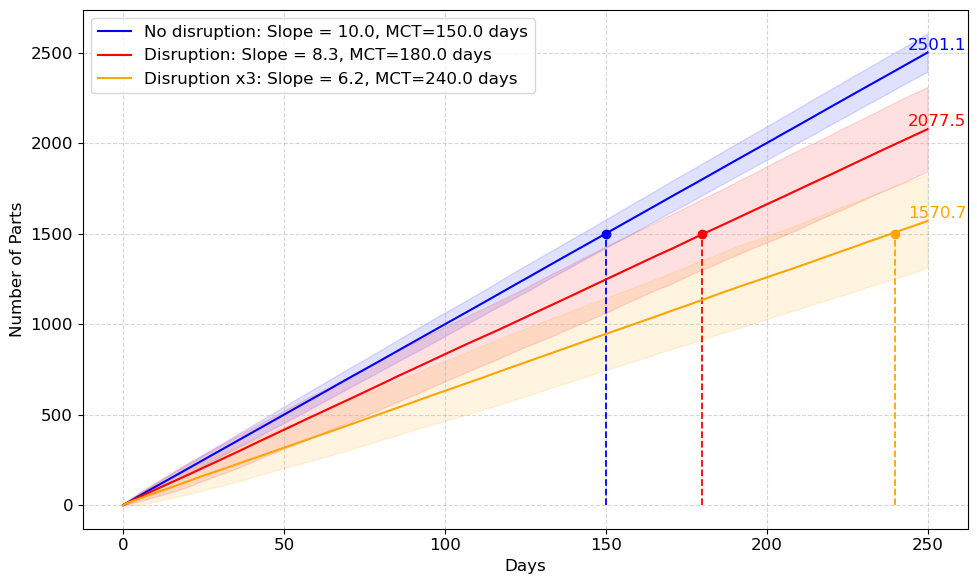

In [18]:
# ============================================================
# compute slope AND mean completion time  E[Tc] together
# ============================================================
def slope_and_MCT(scale, target_units):
    lambda2 = lambda2_base * scale
    availability = lambda3 / (lambda2 + lambda3)
    
    slope = lambda1 * availability                         # effective production rate
    MCT = target_units / slope                             # mean completion time
    
    return slope, MCT


# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []
target_units = 1500                 # SET TARGET HERE

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean and std
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results
# ============================================================
plt.figure(figsize=(10, 6))
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    Slope, MCT= slope_and_MCT(scale, target_units)


    # Plot mean curve
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {Slope:.1f}, MCT={MCT:.1f} days")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # Label at right end
    plt.text(t_grid[-1] - 6, X_mean[-1],f"{X_mean[-1]:.1f}",color=color,va="bottom")
    
    plt.vlines(MCT,                                                   # x-position
               ymin=0,                                                # bottom of the vertical line
               ymax=target_units,                                     # TOP where it touches the target
               color=color,linestyle='--',linewidth=1.3)
    # Marker at the corner
    plt.plot(MCT, target_units,  marker='o', color = color)




plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption_with_MCT_1.png", dpi=200, format="png", bbox_inches="tight")
plt.show()


# - Disruption rates and the initial values with disrupted rate $q_{1,0}=0.001$ and undisrupted rate $q_{0,1}=0.05$ (rare disruption)

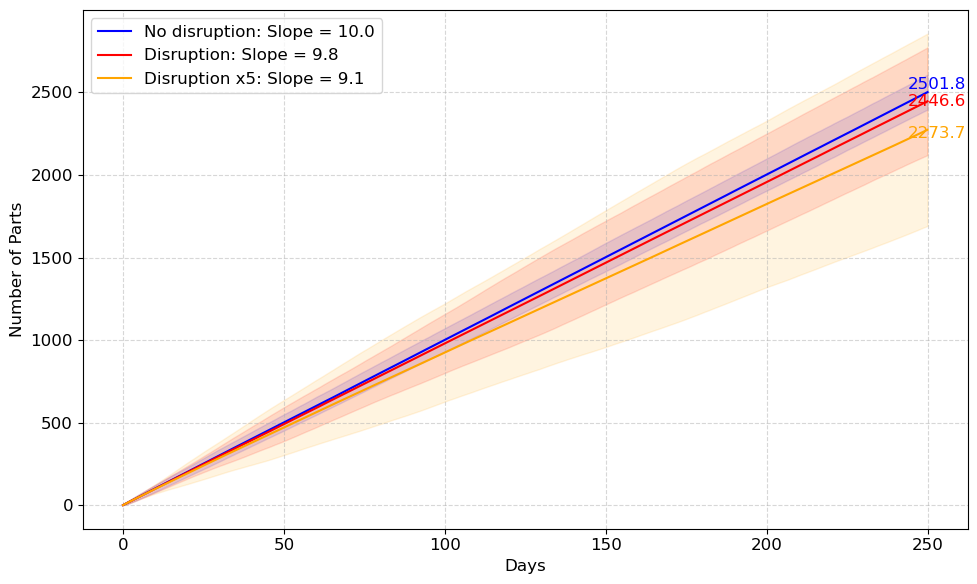

In [20]:
# ============================================================
# System definition: single reaction with disruption
# Y = (X, U1)
# ============================================================
lambda1 = 10.0                     # work (production)
lambda2_base = 0.001               # base failure
lambda3 = 0.05                     # repair

gene_vectors = [
    (+1,  0),   # work
    ( 0, -1),   # failure
    ( 0, +1)    # repair
]

init_state = [0, 1]
max_time = 250
num_simulations = 500

# ============================================================
# Scenario definitions
# ============================================================
scenarios = [
    ("No disruption", 0.0),
    ("Disruption",    1.0),
    ("Disruption x5", 5.0),
]

# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results: mean X(t) for each lambda_2 scenario
# ============================================================
plt.figure(figsize=(10, 6))

# ============================================================
# Slope function
# ============================================================
def slope_from_scale(scale):
    lambda2 = lambda2_base * scale
    return lambda1 * (lambda3 / (lambda2 + lambda3))
    
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    # Plot mean trajectory
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {slope_from_scale(scale):.1f}")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # ---- Auto-label offset logic ----
    if label == "No disruption":
        y_offset = 0
    elif label == "Disruption":
        y_offset = -45
    else:  # "Disruption x5"
        y_offset = -65

    # ---- Place label near the right end ----
    plt.text(t_grid[-1]- 6, X_mean[-1] + y_offset, f"{X_mean[-1]:.1f}", color=color, va="bottom")

plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption2.png", dpi=200, format="png", bbox_inches="tight")
plt.show()    

# - Mean Completion Time with disrupted rate $q_{1,0}=0.001$ and undisrupted rate $q_{0,1}=0.05$ (rare disruption)

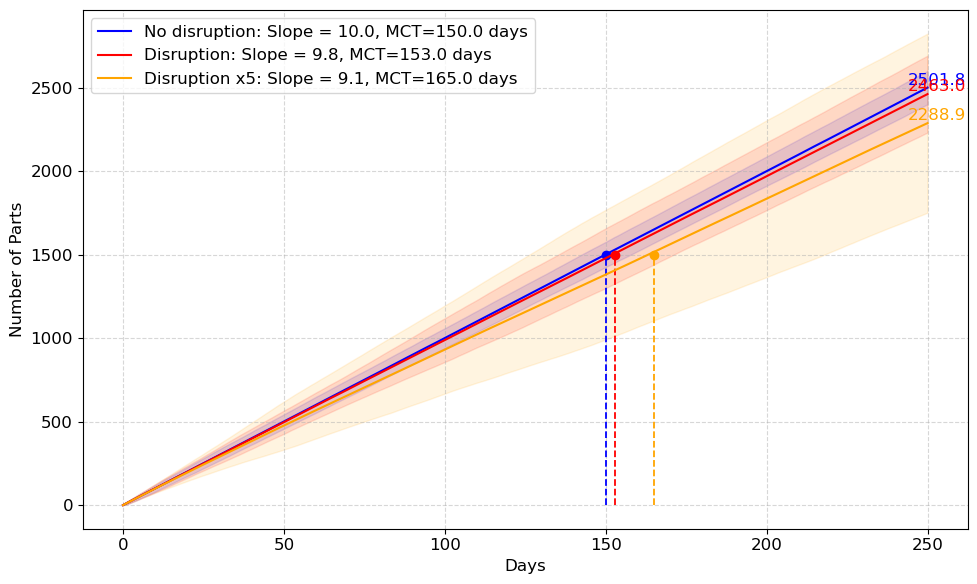

In [21]:
# ============================================================
# compute slope AND mean completion time  E[Tc] together
# ============================================================
def slope_and_MCT(scale, target_units):
    lambda2 = lambda2_base * scale
    availability = lambda3 / (lambda2 + lambda3)
    
    slope = lambda1 * availability                         # effective production rate
    MCT = target_units / slope                             # mean completion time
    
    return slope, MCT


# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []
target_units = 1500                 # SET TARGET HERE

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean and std
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results
# ============================================================
plt.figure(figsize=(10, 6))
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    Slope, MCT= slope_and_MCT(scale, target_units)


    # Plot mean curve
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {Slope:.1f}, MCT={MCT:.1f} days")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # Label at right end
    plt.text(t_grid[-1] - 6, X_mean[-1],f"{X_mean[-1]:.1f}",color=color,va="bottom")
    
    plt.vlines(MCT,                                                   # x-position
               ymin=0,                                                # bottom of the vertical line
               ymax=target_units,                                     # TOP where it touches the target
               color=color,linestyle='--',linewidth=1.3)
   
    # Marker at the corner
    plt.plot(MCT, target_units,  marker='o', color = color)




plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption_with_MCT_2.png", dpi=200, format="png", bbox_inches="tight")
plt.show()


# - Disruption rates and the initial values with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.05$ (rare disruption)

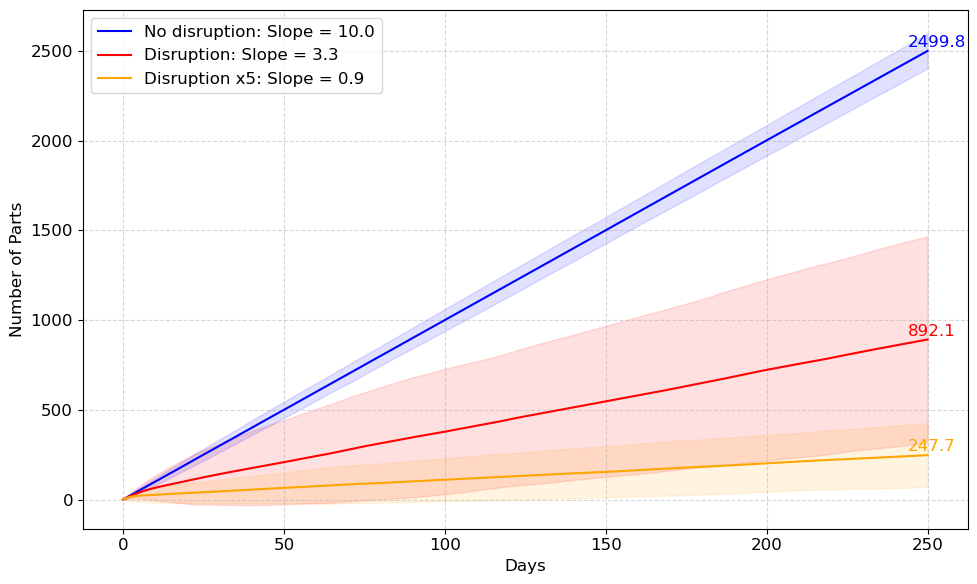

In [26]:
# ============================================================
# System definition: single reaction with disruption
# Y = (X, U1)
# ============================================================
lambda1 = 10.0                     # work (production)
lambda2_base = 0.1               # base failure
lambda3 = 0.05                     # repair

gene_vectors = [
    (+1,  0),   # work
    ( 0, -1),   # failure
    ( 0, +1)    # repair
]

init_state = [0, 1]
max_time = 250
num_simulations = 500

# ============================================================
# Scenario definitions
# ============================================================
scenarios = [
    ("No disruption", 0.0),
    ("Disruption",    1.0),
    ("Disruption x5", 5.0),
]

# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results: mean X(t) for each lambda_2 scenario
# ============================================================
plt.figure(figsize=(10, 6))

# ============================================================
# Slope function
# ============================================================
def slope_from_scale(scale):
    lambda2 = lambda2_base * scale
    return lambda1 * (lambda3 / (lambda2 + lambda3))
    
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    # Plot mean trajectory
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {slope_from_scale(scale):.1f}")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # ---- Auto-label offset logic ----
    if label == "No disruption":
        y_offset = 4
    elif label == "Disruption":
        y_offset = 4
    else:  # "Disruption x5"
        y_offset = 4

    # ---- Place label near the right end ----
    plt.text(t_grid[-1]- 6, X_mean[-1] + y_offset, f"{X_mean[-1]:.1f}", color=color, va="bottom")

plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption3.png", dpi=200, format="png", bbox_inches="tight")
plt.show()    

# - Mean Completion Time with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.05$ (frequent disruption will slow repair)

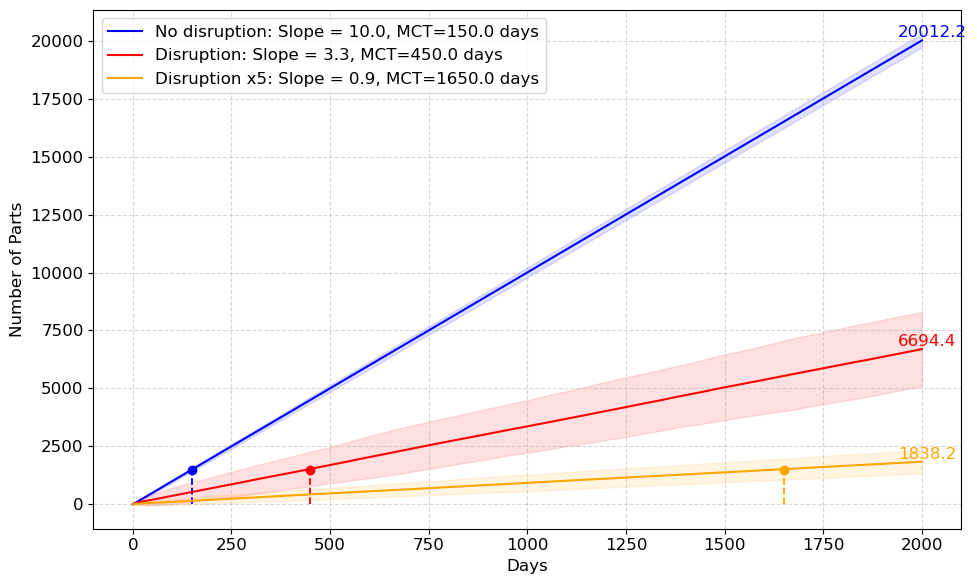

In [40]:
max_time = 2000

# ============================================================
# Helper: compute slope AND mean completion time  E[Tc] together
# ============================================================
def slope_and_MCT(scale, target_units):
    lambda2 = lambda2_base * scale
    availability = lambda3 / (lambda2 + lambda3)
    
    slope = lambda1 * availability                         # effective production rate
    MCT = target_units / slope                             # mean completion time
    
    return slope, MCT


# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []
target_units = 1500                 # SET TARGET HERE

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble mean and std
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results
# ============================================================
plt.figure(figsize=(10, 6))
colors = ["blue", "red", "orange"]

for i, (label, X_mean, X_std) in enumerate(scenario_means_X):
    scale = scenarios[i][1]
    color = colors[i]

    Slope, MCT= slope_and_MCT(scale, target_units)


    # Plot mean curve
    plt.plot(t_grid, X_mean, color=color, linewidth=1.5,label=f"{label}: Slope = {Slope:.1f}, MCT={MCT:.1f} days")

    # Confidence band
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std,alpha=0.12, color=color)

    # Label at right end
    plt.text(t_grid[-1] - 60, X_mean[-1],f"{X_mean[-1]:.1f}",color=color,va="bottom")
    
    plt.vlines(MCT,                                                   # x-position
               ymin=0,                                                # bottom of the vertical line
               ymax=target_units,                                     # TOP where it touches the target
               color=color,linestyle='--',linewidth=1.3)

    # Marker at the corner
    plt.plot(MCT, target_units,  marker='o', color = color)




plt.ylabel("Number of Parts")
plt.xlabel("Days")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("disruption_with_MCT_3.png", dpi=200, format="png", bbox_inches="tight")
plt.show()


# - Simulating Supply Chain Trajectories with Disruptions using the Exact Solution and the Gillespie Method showing the $95\%$ uncertainty bounds for the spread of simulated trajectories

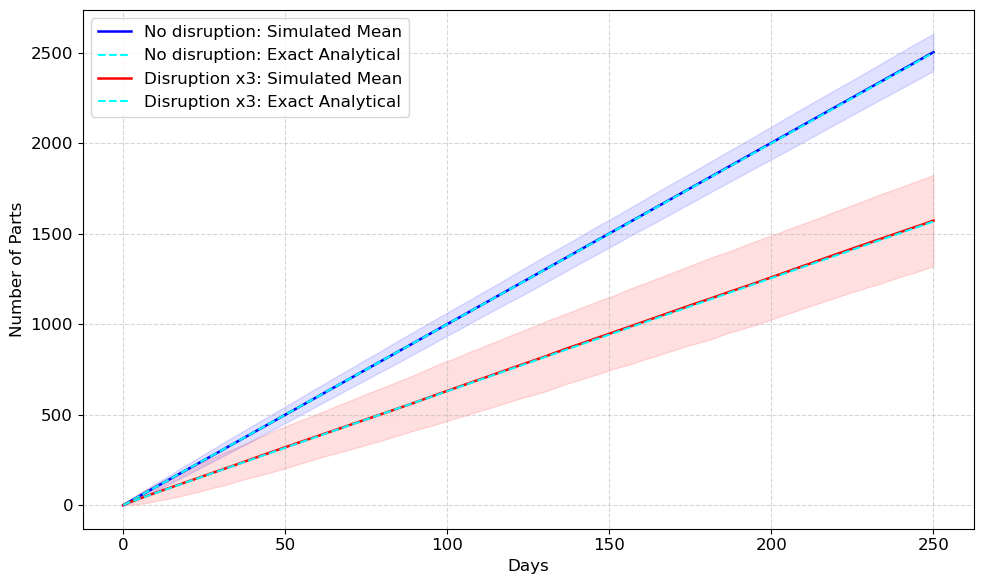

In [195]:
# ============================================================
# System definition: single reaction with disruption
# ============================================================
lambda1 = 10.0                   # work (production)
lambda2_base = 0.1               # base failure
lambda3 = 0.5                    # repair

gene_vectors = [
    (+1,  0),   # work
    ( 0, -1),   # failure
    ( 0, +1)    # repair
]

init_state = [0, 1]
max_time = 250
num_simulations = 500   

# ============================================================
# Scenario definitions
# ============================================================
scenarios = [("No disruption", 0.0), ("Disruption x3", 3.0)]

# ============================================================
# Helper to make a scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop


# ============================================================
# Simulation & averaging
# ============================================================
t_grid = np.linspace(0, max_time, 250)
scenario_means_X = []

for (label, scale) in scenarios:
    prop_fn = propensities(scale)
    all_times, all_states = [], []

    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, max_time)
        all_times.append(times)
        all_states.append(np.array(states))

    # Interpolate onto grid
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    # Ensemble statistics
    X_mean = X_interp.mean(axis=0)
    X_std = X_interp.std(axis=0, ddof=1)
    scenario_means_X.append((label, X_mean, X_std))


# ============================================================
# Plot results: mean X(t) with 95% CI and exact analytical trajectories
# ============================================================
plt.figure(figsize=(10, 6))

def EX_t(t, lambda_1, lambda_2, lambda_3, X_0=0, U_0=1):
    return X_0 + lambda_1 * ((lambda_3 / (lambda_2 + lambda_3)) * t +
        (U_0 - (lambda_3 / (lambda_2 + lambda_3))) *
        ((1 - np.exp(-(lambda_2 + lambda_3) * t)) / (lambda_2 + lambda_3)))

colors = ["blue", "red"]

for (i, (label, scale)) in enumerate(scenarios):
    lam2 = lambda2_base * scale
    X_mean = scenario_means_X[i][1]
    X_std = scenario_means_X[i][2]
    color = colors[i]


    # Plot mean and CI
    plt.plot(t_grid, X_mean, color=color, linewidth=1.8,label=f'{label}: Simulated Mean')
    plt.fill_between(t_grid, X_mean - 2*X_std, X_mean + 2*X_std, alpha=0.12, color=color)  

    # Exact analytical trajectory
    X_exact = EX_t(t_grid, lambda1, lam2, lambda3)
    plt.plot(t_grid, X_exact, '--', color='Cyan', alpha=1, label=f'{label}: Exact Analytical')

# Labels and styling
plt.ylabel('Number of Parts')
plt.xlabel('Days')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the figure as a png
plt.savefig("disruption2_with_exact.png", format='png', bbox_inches='tight') 
plt.show()

# - Simulating Supply Chain Trajectories without Disruptions across Different Time Horizons
# - Disruption rates and the initial values with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.5$

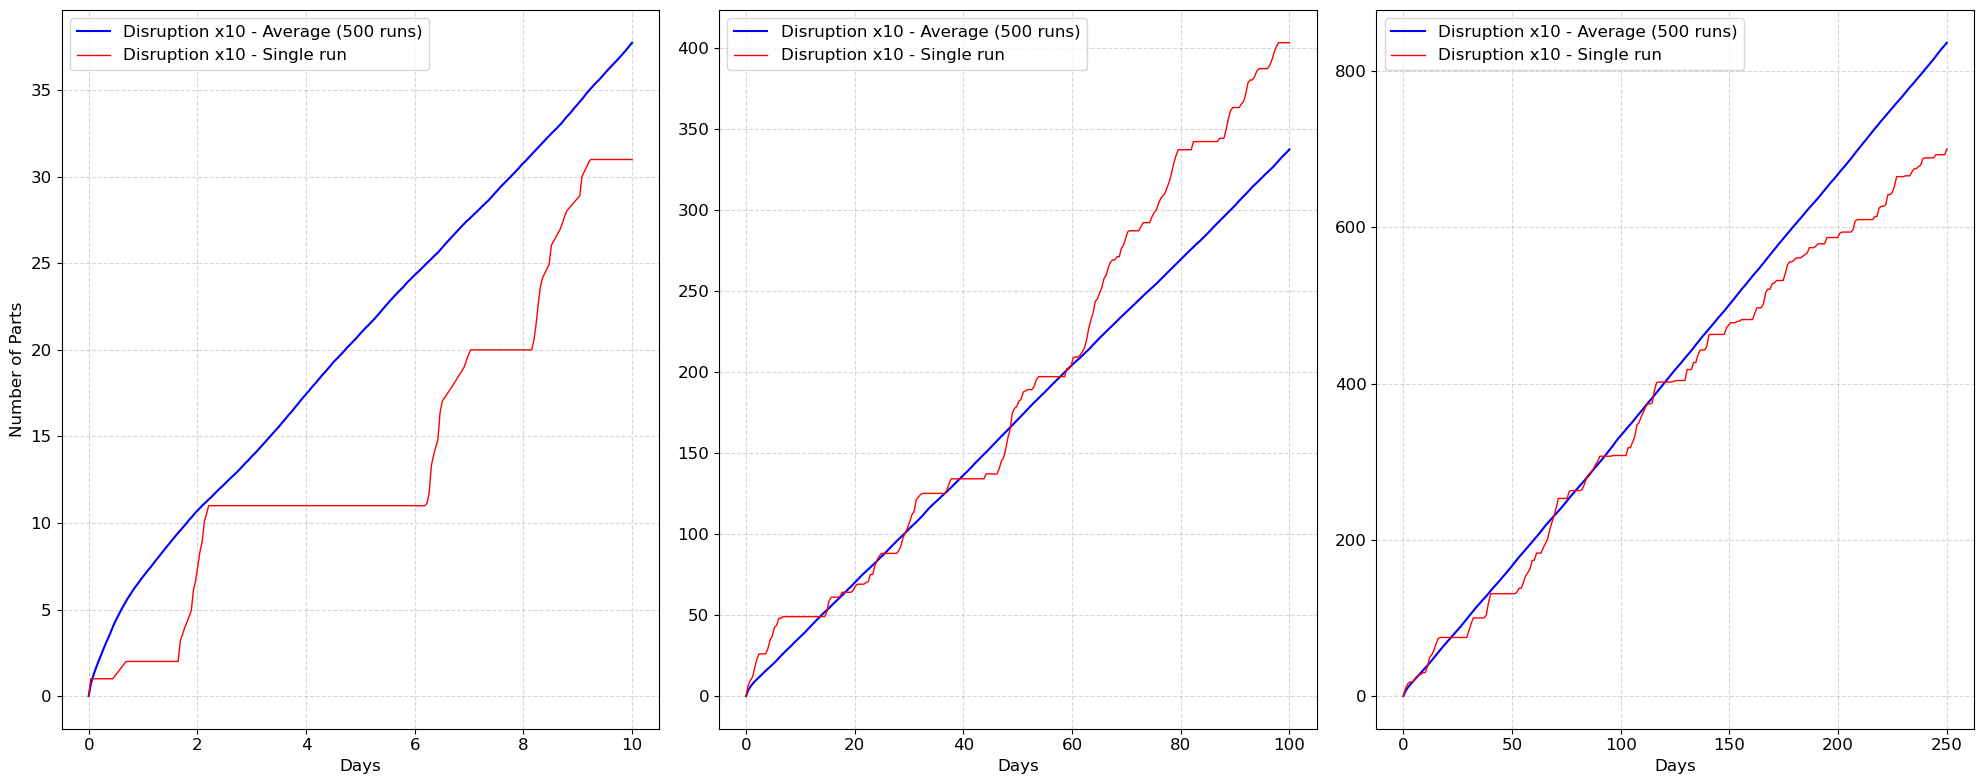

In [135]:
# ============================================================
# System definition: single reaction with disruption
# Y = (X, U1)
# ============================================================
lambda1 = 10.0                # work (production)
lambda2_base = 0.1            # base failure
lambda3 = 0.5                 # repair

gene_vectors = [
    (+1,  0),   # work
    ( 0, -1),   # failure
    ( 0, +1)    # repair
]

init_state = [0, 1]
num_simulations = 500 
max_times = [10, 100, 250]  # horizons → three panels

# ============================================================
# Scenario definitions (scale=0.0 → no failures)
# ============================================================
scenarios = [("Disruption x10", 10.0)]

# ============================================================
# Helper: scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop
    
# ============================================================
# Build one figure with three panels (subplots)
# ============================================================
fig, axes = plt.subplots(1, len(max_times), figsize=(20, 8), sharey=False)
label, scale = scenarios[0]                                         # only one scenario in this script
prop_fn = propensities(scale)

for ax, T in zip(axes, max_times):
    t_grid = np.linspace(0, T, 250)

    # --- Simulations ---
    all_times, all_states = [], []
    for _ in range(num_simulations):
        times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, T)
        all_times.append(np.asarray(times))
        all_states.append(np.asarray(states))

    # --- Interpolate X(t) onto grid for averaging ---
    X_interp = np.zeros((num_simulations, len(t_grid)))
    for i, (times, states) in enumerate(zip(all_times, all_states)):
        X_vals = states[:, 0]
        X_interp[i] = np.interp(t_grid, times, X_vals)

    X_mean = X_interp.mean(axis=0)

    # --- Pick a single trajectory to show (e.g., last simulation) ---
    single_times = all_times[-1]
    single_states = all_states[-1]
    X_single = np.interp(t_grid, single_times, single_states[:, 0])

    # --- Plot in this panel ---
    ax.plot(t_grid, X_mean, color='blue', linewidth=1.5, label=f'{label} - Average (500 runs)')
    ax.plot(t_grid, X_single, color='red', linewidth=1.0, label=f'{label} - Single run')

    # ax.set_title(f'{label} with T = {T} days')
    ax.set_xlabel('Days')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

axes[0].set_ylabel('Number of Parts')
# fig.suptitle('Mean X(t) and Example Trajectory for Different Horizons')
plt.tight_layout()
plt.savefig("disrupt_sml.png", format='png', bbox_inches='tight')  # Save before show

plt.show()

# - Simulating Supply Chain Trajectories with Disruptions across Different Time Horizons
# - Disruption rates and the initial values with disrupted rate $q_{1,0}=0.1$ and undisrupted rate $q_{0,1}=0.5$

In [1]:
# ============================================================
# System definition: single reaction with disruption
# Y = (X, U1)
# ============================================================
lambda1 = 10.0         # work (production)
lambda2_base = 0.1     # base disruption
lambda3 = 0.5          # undisruption

gene_vectors = [
    (+1,  0),             # work
    ( 0, -1),             # disruption
    ( 0, +1)              # undisruption
]

init_state = [0, 1]
num_simulations = 500
max_times = [10, 100, 250]  # horizons → three panels

# ============================================================
# Scenario definitions (scale=0.0 → no failures)
# ============================================================
# scenarios = [("No disruption", 0.0)]
scenarios = [
    ("No disruption", 0.0),
    ("Disruption x10", 10.0),]

# ============================================================
# Helper: scaled propensity function
# ============================================================
def propensities(lambda2_scale):
    lam2 = lambda2_base * lambda2_scale
    def prop(state):
        X = int(state[0])
        U1 = int(state[1])
        return [
            lambda1 * U1,        # work
            lam2 * U1,           # failure (scaled)
            lambda3 * (1 - U1)   # repair
        ]
    return prop
    
# ============================================================
# Build one figure with three panels (subplots)
# ============================================================
# --- grid: rows = scenarios, cols = horizons ---
n_rows = len(scenarios)
n_cols = len(max_times)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 6.5*n_rows), sharey=False)

for r, (label, scale) in enumerate(scenarios):
    prop_fn = propensities(scale)
    for c, T in enumerate(max_times):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        t_grid = np.linspace(0, T, 250)

        # --- Simulations ---
        all_times, all_states = [], []
        for _ in range(num_simulations):
            times, states = gillespie_algorithm(init_state, gene_vectors, prop_fn, T)
            all_times.append(np.asarray(times))
            all_states.append(np.asarray(states))

        # --- Interpolate X(t) onto grid for averaging ---
        X_interp = np.zeros((num_simulations, len(t_grid)))
        for i, (times, states) in enumerate(zip(all_times, all_states)):
            X_vals = states[:, 0]
            X_interp[i] = np.interp(t_grid, times, X_vals)

        X_mean = X_interp.mean(axis=0)

        # --- one example trajectory ---
        single_times = all_times[-1]
        single_states = all_states[-1]
        X_single = np.interp(t_grid, single_times, single_states[:, 0])

        # --- plot ---
        ax.plot(t_grid, X_mean, linewidth=1.5, color ='blue', label='Average of 500 runs')
        ax.plot(t_grid, X_single, linewidth=1.0, color ='red', label='Single run')

        if r == 0:
            ax.set_title(f'{label} with T = {T} days')
        elif r == 1:
            ax.set_title(f'{label} with T = {T} days')
        if c == 0:
            ax.set_ylabel('Number of Parts')

        ax.set_xlabel('Days')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig("disrupt_sml2.png", format='png', bbox_inches='tight')  # Save before show
plt.show()
